In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay


In [3]:
df = pd.read_excel('cleaned_data.xlsx')
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 148670
Columns: 46


In [12]:
y = df['Status']
X = df.drop('Status', axis=1)

print("Features (X): ", X.shape[1], "columns")
print("Target (y) - default rate:", round(y.mean() * 100, 1), "%")

Features (X):  48 columns
Target (y) - default rate: 24.6 %


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 118936
Testing rows: 29734


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training rows:", len(X_train))


Training rows: 118936


In [21]:
# Force all columns to numeric, anything that can't convert becomes NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Now replace infinity and fill nulls
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("Any nulls?", X.isnull().any().any())
print("Shape:", X.shape)

Any nulls? False
Shape: (148670, 48)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)
print("Model trained")

Model trained


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    class_weight='balanced',
    max_iter=3000,
    random_state=42
)

model.fit(X_train_scaled, y_train)
print("Model trained, no warnings")

Model trained, no warnings


In [26]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {round(auc, 3)}")

ROC-AUC Score: 0.852


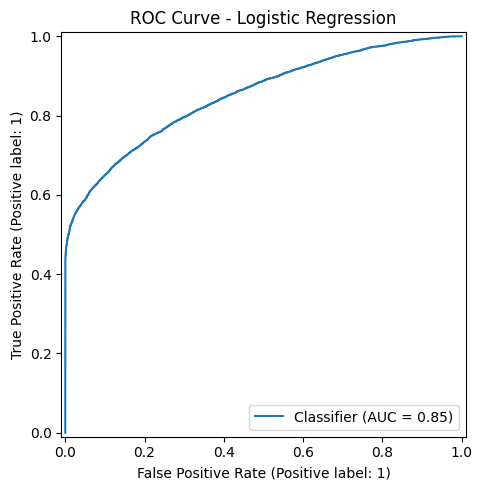

In [28]:

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title('ROC Curve - Logistic Regression')
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

In [29]:
df['default_probability'] = model.predict_proba(X)[:, 1]
df.to_excel('scored_data.xlsx', index=False)
print("Saves scored_data.xlsx")

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saves scored_data.xlsx
